# Machine Learning - Classification

Here we will do a study on Machine Learning Classification using completely hypothetical data.    

## Summary

In this study, we create the data which means that we absolutely know things about the data. The ML model is used to reverse engineer the characteristics that we built in. Since we know the *truth* of the data, we can explore the *value* of the ML model—its predictions and statistics.  

For example, we know that **gender** makes a *genuine* difference in the accuracy of the predictions. When we ask our code to give us statistics (e.g., Accuracy, Feature Importance), we can interpret these numbers with full understanding of "the truth" to know that **gender** is an important feature.  

In normal research, we do not know *the truth* of the data. All we have are the results of the ML model. We need to be able to accurately and fairly interpret the model so that value is added.  

In this study, students should learn:

- How to create and analyze a Classification model  
- Accuracy can be misleading in a multitude of ways  
- Calculating accuracy is not the stopping point of the research  
- That graphing a model's predictions reveals important information & insight  
- Feature Importance reflects how much a feature is used in making a model's decisions, but that does not mean the feature is, in practice, (un)important in a Fair & Ethical ML model.  
- With limited data, a model's accuracy may be *"wrong"*   
- Using a randomized test set won't always reveal that the model is overly complex or convoluted.  

## Data Overview

In this hypothetical example, we know the **height** and **gender** of about 2000 people who are between the ages of 22-32. We also know whether they play in the NBA (or WNBA). Let's see if a `DecisionTreeClassifier` can accurately predict whether they play in the NBA or not based solely on their gender and height. Note that for simplicity, we will only consider male/female, and we will often say just NBA when we also mean to include WNBA.  

We will break up our study into two primary sections. Each section uses completely contrived and made-up data. This allows us to understand the model's results. In both cases, **height** impacts the results (playing for NBA), but the specifics of how it impacts the results is different in each study.  

In our first dataset, the threshold for automatically being in the NBA is 81+ inches tall for a male, while a woman must be only 75+ inches tall.  

The two data types are:  

1. **Predictable Data**: A person is in the NBA based entirely on their height.  
2. **Randomized Data**: The taller a person is, the more likely they are in the NBA.

**Example Data**  

::::{tab-set}

:::{tab-item} Predictable

A person is in the NBA when they are tall enough. Nothing else matters. On the right, you can see the people who are tall enough. Men need to be 81 inches tall. Women need to be 75 inches tall.  

![Predictable Data](./class_nba_data.png) 

![Predictable Data](./class_nba_data_in_nba.png)

:::

:::{tab-item} Randomized
In this data, your height provides the chances that you're in the NBA. There will be people who are tall enough but are not in the NBA, and there will be relatively short people who are in the NBA. But, the really tall people have a greater chance of being in the NBA.

![Randomized Data](./class_nba_rand_data.png) 

![Randomized Data](./class_nba_rand_data_in_nba.png)

:::

::::

## The code
There are several parameterized methods used to create the data, models, and graphs. Seeing the code can help the student understand the results as well as to reproduce similar studies.  



Accuracy: 99.50%
Feature: height, Importance: 100.00%
Equal Opportunity (FNR): 100%
Predictive Equality (FPR): 0%
Equal Opportunity (FNR): 0%
Predictive Equality (FPR): 0%


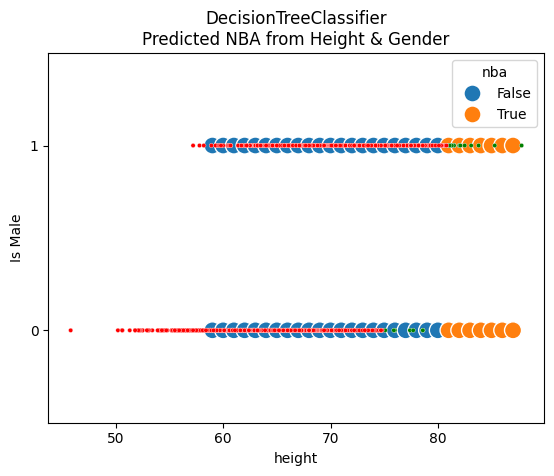

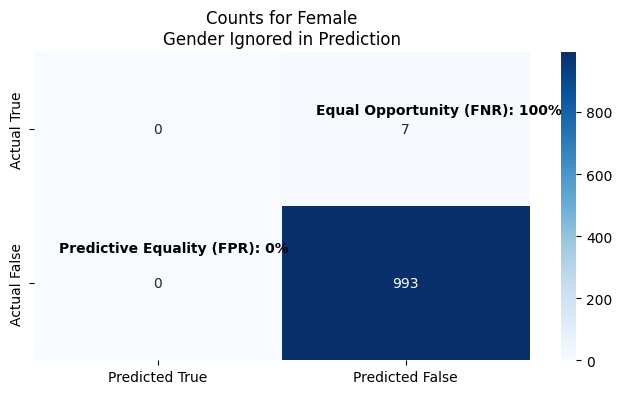

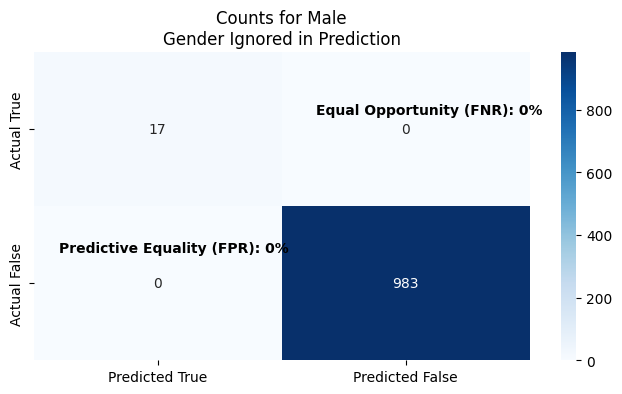

In [12]:
"""
This code implements a machine learning classification study on hypothetical NBA data.

The plot_nba_predictions function creates a visualization that shows:
- Large blue/orange dots: The model's predictions of who is in the NBA (NBA players) or not (non-NBA).
  - Blue dots represent predicted NBA players (men and women combined in the prediction).
  - Orange dots represent predicted non-NBA players.
- Small red/green dots: The actual data from our generated dataset overlaid on top.
  - Green dots: People who are actually in the NBA.
  - Red dots: People who are actually not in the NBA.

This overlay helps visualize how well the model's predictions match the real data, revealing accuracy and potential biases.
"""
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import seaborn as sns


def in_nba(height, male, basis):
    """
    Chances of being in NBA increase when one is taller than some cutoff.
    Normal and short people have a 'basis' chance.
    """
    # pick the cutoffs based on the gender of the person
    cutoffs = [[85, 82, 80], [76, 74, 72]][0 if male else 1]
    if height > cutoffs[0]:
        basis *= 60
    elif height > cutoffs[1]:
        basis *= 20
    elif height > cutoffs[2]:
        basis *= 10

    return random.random() < basis


def in_nba_by_height(height, male, ignored):
    return (male and height >= 81) or (not male and height >= 75)


def get_nba_data(size, basis, nba_method=in_nba):
    # This uses Numpy to create a normal distribution around some mean with
    # some standard deviation. https://youtu.be/rzFX5NWojp0
    # use Numpy concatenate to make a single list of values rounded to 1 decimal place
    men_height = np.random.normal(71, 5, size)
    women_height = np.random.normal(64, 5, size)
    height = np.concatenate([men_height, women_height])
    height = np.round(height, decimals=1)
    # Create a list of size having 'Male' as every value
    # use 'extend' to 'concatenate' another list to the end
    # if we used 'append' then only 1 element, a list, would get added
    genders = ["Male"] * size
    genders.extend(["Female"] * size)
    # Create the True/False values for being in the NBA based on height & gender
    nba = [nba_method(h, g == "Male", basis) for h, g in zip(height, genders)]
    df_sorted = pd.DataFrame(data={"gender": genders, "height": height, "nba": nba})
    # shuffle the dataframe rows so that we don't have all males at the top
    df_height = df_sorted.sample(frac=1).reset_index(drop=True)
    return df_height


def model_acc(features, labels, test_size=0.3, **kwargs):
    # Create an untrained model
    model = DecisionTreeClassifier(**kwargs)

    # Split the data into training and testing sets
    train_f, test_f, train_l, test_l = train_test_split(
        features, labels, test_size=test_size
    )

    # Fit the model to the training data
    model.fit(train_f, train_l)

    # get the accuracy of our model
    label_predictions = model.predict(test_f)
    print(f"Accuracy: {accuracy_score(test_l, label_predictions):.2%}")

    # get importance
    importance = model.feature_importances_
    # summarize feature importance
    for index, feat_importance in enumerate(importance):
        print(f"Feature: {features.columns[index]}, Importance: {feat_importance:.2%}")
    # plot feature importance
    plt.bar(x=features.columns, height=importance)
    plt.title("Feature Importance")
    return model


def run_nba(randomized=False, size=1000, basis=0.005, keep_gender=True, max_depth=3, nba_method=None):
    if nba_method is None:
        nba_method = in_nba if randomized else in_nba_by_height
    df_height = get_nba_data(size, basis, nba_method)

    labels = df_height["nba"]
    # translate the 'gender' column, a string, to a boolean 'male' column
    df_height["male"] = df_height["gender"] == "Male"
    # get our feature columns; honor our keep_gender argument
    features = df_height[["male", "height"] if keep_gender else ["height"]]

    model_nba = model_acc(features, labels, max_depth=max_depth)

    return model_nba, features, df_height


def plot_nba_predictions(model, actual=None, keep_gender=True):
    plt.clf()
    # create features to predict
    height = [t for t in range(59, 88)]
    genders = [False] * len(height)
    gender_m = [True] * len(height)
    genders.extend(gender_m)
    height.extend(height)
    features = pd.DataFrame(data={"male": genders, "height": height})
    model_features = features if keep_gender else pd.DataFrame(data={"height": height})
    features["nba"] = model.predict(model_features)

    sns.scatterplot(
        x=features["height"],
        y=features["male"],
        hue=features["nba"],
        legend="full",
        s=150,
    )
    if actual is not None:
        colors = ["red", "green"]
        sns.scatterplot(
            x=actual["height"],
            y=actual["male"],
            hue=actual["nba"],
            palette=colors,
            legend=False,
            s=10,
        )

    plt.title("DecisionTreeClassifier\nPredicted NBA from Height & Gender")
    plt.yticks([0, 1])
    plt.ylim(-0.5, 1.5)
    plt.ylabel("Is Male")


def plot_confusion_matrix(df, features, model, gender=0):
    # Update the title depending on whether features has 'male' as a column.
    gender_for_title = "Male" if gender == 1 else "Female"

    if "male" in features.columns:
        gender_for_title += "\nGender Included in Prediction"
        feature_list = ["male", "height"]
    else:
        gender_for_title += "\nGender Ignored in Prediction"
        feature_list = ["height"]

    # filter to a gender
    df_filtered = df[df["male"] == gender]
    features = df_filtered[feature_list]
    actual = df_filtered["nba"]

    # get our predictions
    predicted = model.predict(features)
    # Calculate confusion matrix
    confusion = confusion_matrix(actual, predicted, labels=[0, 1])

    # Calculate the rates of accuracy for each quadrant
    # get the counts
    tn, fp, fn, tp = confusion.ravel()
    # FNR (Equal opportunity): #fn / (actual positives)
    actual_positives = df_filtered["nba"].sum()
    fnr = np.nan if actual_positives == 0 else fn / actual_positives
    # FPR (Predictive Equality): #fp / (actual negatives)
    actual_negatives = len(df_filtered) - df_filtered["nba"].sum()
    fpr = np.nan if actual_negatives == 0 else fp / actual_negatives
    print(f"Equal Opportunity (FNR): {fnr:.0%}")
    print(f"Predictive Equality (FPR): {fpr:.0%}")

    # Create a table for visualization
    data = {"Predicted True": [tp, fp], "Predicted False": [fn, tn]}

    table_df = pd.DataFrame(data, index=["Actual True", "Actual False"])

    # Plot the table using Seaborn's heatmap
    plt.figure(figsize=(8, 4))
    sns.heatmap(table_df, annot=True, fmt="d", cmap="Blues")
    ax = plt.gca()
    ax.annotate(
        f"Equal Opportunity (FNR): {fnr:.0%}",
        (1.0, 0.40),
        xytext=(25, 0),
        textcoords="offset points",
        weight="bold",
    )
    ax.annotate(
        f"Predictive Equality (FPR): {'N/A' if np.isnan(fpr) else f'{fpr:.0%}'}",
        (0.1, 1.30),
        xytext=(0, 0),
        textcoords="offset points",
        weight="bold",
    )
    plt.title("Counts for " + gender_for_title)

model, features, df_height = run_nba(keep_gender=False)

plot_nba_predictions(model, df_height, keep_gender=False)
plot_confusion_matrix(df_height, features, model, gender=0)
plot_confusion_matrix(df_height, features, model, gender=1)
plt.show()

## Data 1: Predictable Data Study

In this contrived dataset, we say that whether a person is in the NBA is completely determined by their height. We use the `in_nba_by_height` method (in the **Code** section above). We see that the accuracy is very, very high—nearly 100%! This kind of makes sense because we've generated the data in a way to be predictable.    

Belonging to the NBA in this *Predictable Data Study* is very simple: if you're tall enough for your gender, you're in! When we look at the *Feature Importance*, we see that **height** has an importance of 60% while **gender** is ~40%. 

**Model Predictions Drawn**  
In this graph, we see both how the actual data is distributed and how the predictions are made. The predictions are shown with the larger, blue and orange dots. On top of predictions are smaller, red and green dots that represent the actual data. It shows that the model does a great job! The picture says a lot, and you should find it useful in concluding that the model is sound.  

![Simple Data Predictions](./class_nba_results.png)  

So what? Where do we go from here?  

Let's present a few questions:  
- How important is **gender** in the predictions?  
- What does the 40% mean?  

We will explore this by removing **gender** from the set of features available to the model when making its predictions. 

:::{admonition}Make your prediction
> Take a minute to think and make some predictions about what will happen when we remove **gender** from the feature set. 
:::

:::{admonition}An Aside
> When the percentage of actual women in WNBA drops to less than 1% (say, 2/500 women), then the *Feature Importance* drops to just ~6%. **What does that say about Feature Importance?**  
>
> Read on and hopefully it will all make sense.
:::

### Gender Included (Baseline)
First, let's run the model with gender included to establish a baseline.

Expected output: High accuracy (~100%), balanced fairness metrics.

Accuracy: 99.67%
Feature: male, Importance: 31.46%
Feature: height, Importance: 68.54%
Equal Opportunity (FNR): 11%
Predictive Equality (FPR): 0%
Equal Opportunity (FNR): 0%
Predictive Equality (FPR): 0%


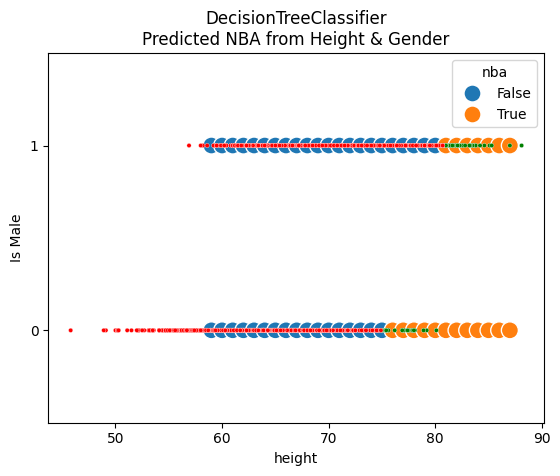

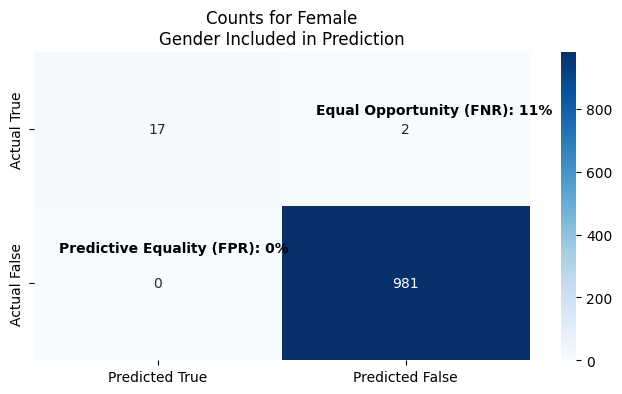

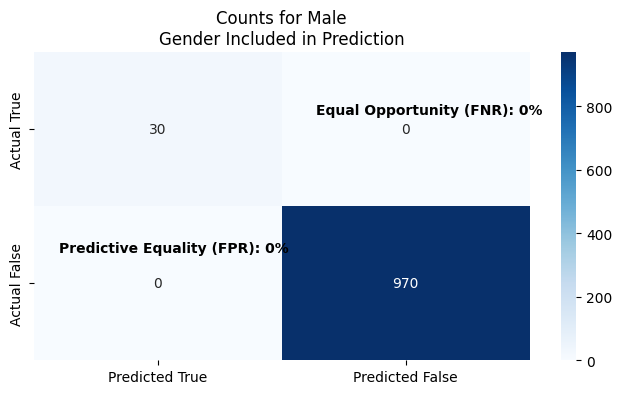

In [10]:
model_included, features_included, df_included = run_nba(keep_gender=True)
plot_nba_predictions(model_included, df_included, keep_gender=True)
plot_confusion_matrix(df_included, features_included, model_included, gender=0)
plot_confusion_matrix(df_included, features_included, model_included, gender=1)
plt.show()

### Gender Removed

Here are the results when **gender** is removed. I find the results fascinating! First off, the accuracy of the model is 99.5%!! Were you expecting that?  

How in the world does the model predict with 99.5% accuracy when we ignore **gender**, which has a *Feature Importance* of 40%?  

What we see in the graph is that the model doesn't predict NBA until one is 80 inches tall. In this particular dataset, only one woman is 80 inches or taller (and thus correctly predicted as NBA), while 12 other women who are actually in the WNBA are shorter than 80 inches and are incorrectly predicted as not in the NBA. This results in a high false negative rate for females, as the model fails to identify most WNBA players due to the height-only threshold.

![No Gender Model Results](./class_no_gender.png)    

#### Discussion   

We are left to reflect about the meaning of Accuracy when it completely clobbers a segment of the population. Without knowing the error rates, the Accuracy number alone loses significance.  

We must also question what the *Feature Importance* really means. In this scenario, we can predict with nearly 100% accuracy who is in the NBA even when excluding a feature with 40% importance.   

In this study, the count of people at various heights is random, and the training set is randomly selected. This leads to getting different numbers each time we run the code. The greatest variance was in the *Feature Importance* of **gender**. The accuracy was always very close to 100%.  

So, is gender an important feature to have in the model? The answer depends on whether you want to be *Fair* or not. If all you care about is overall accuracy, you could ignore **gender**, which simplifies your model. But, then, you're not fair! Let's examine Fairness more.

#### Fairness

Fairness is covered [here](../lectures/fairness). What is especially important is to know the definitions of fairness and how we can discuss fairness scientifically once we define it.

Let's say that in our new model we choose to ignore **gender** because we've seen how overall Accuracy is still very high. What happens?

We see that the model's predictions for men are still very good, and it basically ignores that women are shorter on average. This means that we have bad Fairness as measured by Equal Opportunity: there are too many False Negatives and not enough (or any) True Positives.

In other words, the True-Positive rate (the ability to correctly identify WNBA players) for women is near 0%. This is also called PPV (Positive Predictive Value) [Video Reference](https://youtu.be/QqgJHryKOSU).  

To be Fair, you want FNR and FPR to be relatively close across all the groups. If you look at these two graphs, you'll see that FNR for Females is 92% while Males is at 0%!! This leads us to conclude that the model is **NOT FAIR** when we exclude **gender** from the features.  

::::{tab-set}

:::{tab-item}Female

![Female Fairness](./class_female_fairness.png)

:::

:::{tab-item}Male

![Male Fairness](./class_male_fairness.png)  

:::

::::

#### Summary
*Feature Importance*: Each feature is given a percentage amount that reflects how much that feature is used in the Decision Tree. The sum of all the importance values will total 100%.   

*Feature Importance* does **NOT** necessarily reflect how accurate the model will be if that feature is removed from consideration.  

Plotting the model's predictions provides a lot of information.  

Calculating *Fairness* values is important when evaluating a model.  

### Class Activity: Modify Thresholds and Observe Bias

In this hands-on activity, you'll experiment with changing the height thresholds for NBA eligibility and see how it affects model accuracy and fairness.

**Instructions**:

1. Modify the `in_nba_by_height_custom` function below to change the thresholds (e.g., set `female_threshold=70` to make it more likely for women to be in NBA compared to men).
2. Re-run the model with `run_nba(keep_gender=False)` using the custom function (update `get_nba_data` to pass `nba_method=in_nba_by_height_custom`).
3. Observe the changes in accuracy, feature importance, and fairness metrics (FNR for females).
4. Predict beforehand: How will lowering the female threshold affect the model's single height threshold and bias when gender is ignored? Discuss with your teammate.

Accuracy: 99.50%
Feature: height, Importance: 100.00%


,gender,height,nba,male
0,Male,69.0,False,True
1,Male,64.1,False,True
2,Female,57.7,False,False
3,Female,54.6,False,False
4,Female,59.0,False,False
...,...,...,...,...
1995,Female,62.0,False,False
1996,Female,65.6,False,False
1997,Male,72.2,False,True
1998,Female,60.4,False,False


Equal Opportunity (FNR): 100%
Predictive Equality (FPR): 0%
Equal Opportunity (FNR): 0%
Predictive Equality (FPR): 0%


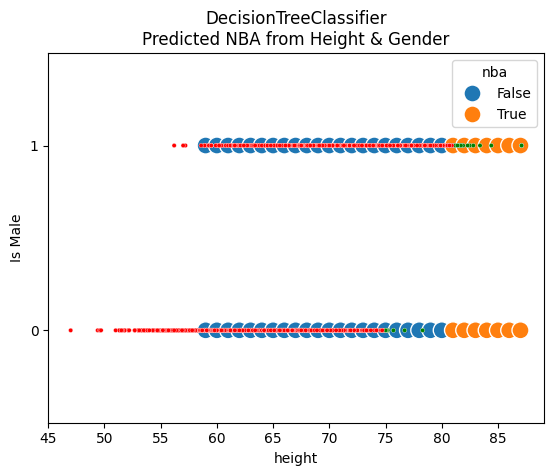

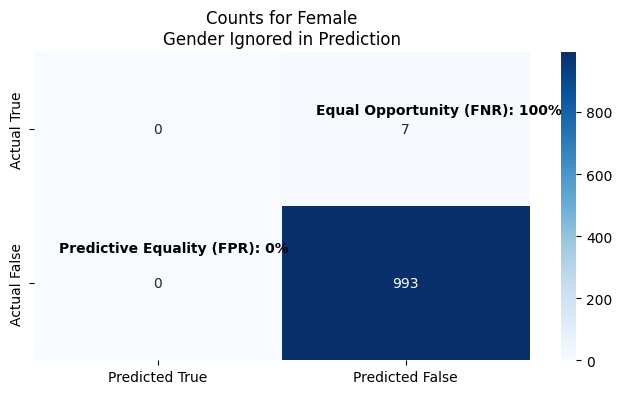

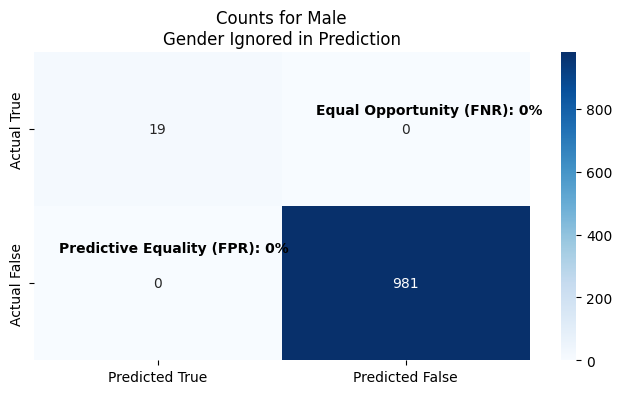

In [ ]:
def in_nba_by_height_custom(height, male, ignored):
    # Customize thresholds here (change as needed)
    female_threshold = 75  # Default; lower for the experiment
    male_threshold = 81
    return (male and height >= male_threshold) or (not male and height >= female_threshold)

# Example: Change to female_threshold=65, male_threshold=81

# Then update get_nba_data call in run_nba or create a new run function.

# --- Your Solution Here ---


**Discussion Questions**:
- Is this fair? Why might real-world thresholds be adjusted?
- How does this relate to bias in ML models?

## Data 2: Advanced Randomized Data Study

In this sub-study, we will create data that is more random. Surely not everyone who is very tall is in the NBA; they are simply more likely to be in the NBA. 

::::{tab-set}

:::{tab-item}Trial #1

In this trial:  
- We set `basis=0.01` for a slightly greater chance of being in the NBA.  
- We got 49 people to be in the NBA.
- We let the `max_depth=6` for the Decision Tree.
- We allowed gender to be considered.   
You can see that there are very few small, green dots (representing True NBA players) that are incorrectly categorized. There are a few randomly scattered large, blue dots (representing predicted NBA players). These scattered dots reflect the model's attempt to learn and predict the inherent randomness in the data.  

![Random #1 Predictions](./class_nba_rand_results.png)

> **OUTPUT**  
> Accuracy: 97.67%  
> Feature: male, Importance: 2.38%  
> Feature: height, Importance: 97.62% 

The Fairness comparison for Male/Female shows that the model appears to be *fair*, meaning that the False-Negative-Rates across genders are not disparately out of whack.
   
| Gender | Equal Opportunity | Predictive Equality |
|--------|-------------------|---------------------|
| Female | 73%               | 0%                  |
| Male   | 59%               | 0%                  |

:::

:::{tab-item}Trial #2

In this trial:  
- We keep `basis=0.01` for a slightly greater chance of being in the NBA.  
- We got 42 people to be in the NBA.  
- We let the `max_depth=3` for the Decision Tree; this is to reduce overfitting.
- We allowed gender to be considered.   
You can see that randomness in the prediction went away, which was expected since we set `max_depth=3`. What is unexpected though is that we still have ~98% accuracy, and the *Feature Importance* for **gender** dropped to zero!  

![Random #2 Predictions](./class_nba_rand_results_2.png)

> **OUTPUT**  
> Accuracy: 97.67%  
> Feature: male, Importance: 0.00%  
> Feature: height, Importance: 100.00% 

The Fairness comparison for Male/Female shows that the model appears to be *fair*, meaning that the False-Negative-Rates across genders are not disparately out of whack. However, it might be better to say that the model is equally ***UN**fair* because the False Rates are pretty high for both genders. Effectively, the high accuracy rate occurs because there are so few people in the NBA.  

| Gender | Equal Opportunity | Predictive Equality |
|--------|-------------------|---------------------|
| Female | 100%              | 0%                  |
| Male   | 86%               | 0%                  |

:::

:::{tab-item}Trial #3

In this trial:  
- We keep `basis=0.03` for a significantly greater chance of being in the NBA.  
- We got 102 people to be in the NBA.  
- We let the `max_depth=6` for the Decision Tree—we may overfit.
- We allowed gender to be considered.   
You can see that randomness in the prediction went away, which was **UN**expected since we set `max_depth=6`. We still have a high accuracy.  

![Random #3 Predictions](./class_nba_rand_results_3.png)

> **OUTPUT**  
> Accuracy: 96.17%  
> Feature: male, Importance: 37.17%  
> Feature: height, Importance: 62.83% 

The Fairness comparison for Male/Female shows it to be quite (un)fair:  

| Gender | Equal Opportunity | Predictive Equality |
|--------|-------------------|---------------------|
| Female | 74%               | 0%                  |
| Male   | 88%               | 0%                  |  

This image of the Decision Tree is small and hard to read. The blue boxes predict NBA while the others predict not. You can see that virtually every path leads to False (not in NBA). A rather silly tree.  

![Decision Tree for NBA](./class_nba_rand_model_3.png)   

Did we land a good model? Perhaps it is the best we can do, but the inability to accurately predict players in the NBA is horrible. It fails to predict 74% of the NBA women and 88% of the NBA men. That's a lot! 

:::

::::

This output is generated from the `model_acc` code in the prior section. It is a bit surprising to think that the model achieved ~99% accuracy while predicting that every male will 

> **OUTPUT**  
> Feature: male, Importance: 0.00%  
> Feature: height, Importance: 100.00%

This graphic shows that our tree is relatively simple. It shows that it always looks at height, and it predicts in the NBA in only 1 small case.  

![NBA Model](./fi_model_nba.png)